# NFL Playing Surface, Temperature, and Lower-Extremity Injuries EDA Project

## What this EDA is about

This notebook explores whether the **playing surface** (artificial turf vs. natural grass) and **game-time temperature** are related to how often players show up on the weekly injury report with a **lower-extremity injury** (knee, ankle, hamstring, groin, calf/quad, foot/Achilles, and other smaller lower body injuries such as hip, pelvis, glute, adductor, foot, toe, heel, shin, tibia,  and fibula).

**Research question:** Among NFL team-weeks, is the rate of lower-extremity injury-report entries higher for teams playing on turf than on grass, and is that difference moderated by temperature?

That breaks into three parts:
1. **Surface effect** - do turf team-weeks have a higher lower-extremity injury rate than grass team-weeks?
2. **Temperature effect** - among outdoor/open-air games, does colder temperature correlate with a higher rate, independent of surface?
3. **Interaction** - is the turf-vs-grass gap larger in cold weather than in warm weather / dome-equivalent conditions?

**Data source:** everything comes straight from the `nflreadpy` API for seasons 2021-2025.
- `nfl.load_schedules(seasons=[2021, 2022, 2023, 2024, 2025])` - game-level schedule data, including `surface`, `roof`, and `temp`.
- `nfl.load_injuries(seasons=[2021, 2022, 2023, 2024, 2025])` - weekly injury report entries per player, per team, per week.

**Unit of analysis:** a **team-week** (one team, one week, one season) rather than an individual injury-report row. For each team-week I compute the **number of lower-extremity injury-report entries** for that team and attach the surface, roof, and temperature of the game that team played that week. Because one team-week is exactly one game, a count per team-week is already a per-game rate, with the exposure carried by the number of rows rather than hidden inside a ratio - joining on `team` + `week` + `season` rather than `home_team` only, since a team's surface/temp exposure is whichever stadium hosted their game that week, home or away.

**Roadmap:**
1. Load and clean the game schedule data (already done below) - handle missing `temp` by dropping open/outdoors games with no reading and filling dome/closed-roof games with 72 degrees.
2. Load the injury reports via the API and classify each entry as lower-extremity or not.
3. Aggregate injuries to the team-week level and join in that week's surface/roof/temp.
3b. Check that the outcome metric measures what I think it measures before trusting any comparison built on it.
4. Compare lower-extremity injury rates by surface, by temperature, and by their interaction.

## Sources I read

**Venishetty, N., Xiao, A. X., Ghanta, R., Reddy, R., Pandya, N. K., & Feeley, B. T. (2024). Lower extremity injury rates on artificial turf versus natural grass surfaces in the National Football League during the 2021 and 2022 seasons. *Orthopaedic Journal of Sports Medicine, 12*(8).** [Link](https://doi.org/10.1177/23259671241265378)

This is the closest match to what I did. Same league, same surfaces, same body parts. They looked at 718 injuries and found 1.42 leg injuries per game on turf and 1.22 on grass, so turf came out worse for them. They also checked whether weather mattered and found it did not change the odds of a season-ending surgery. The big difference is what we each counted. They used real recorded game injuries and surgeries. I used names on the weekly injury list, which is a much rougher measure, so it makes sense that I could not see a gap they did see.

**Gould, H. P., Lostetter, S. J., Samuelson, E. R., & Guyton, G. P. (2023). Lower extremity injury rates on artificial turf versus natural grass playing surfaces: A systematic review. *The American Journal of Sports Medicine, 51*(6), 1615-1621.** [Link](https://doi.org/10.1177/03635465211069562)

These authors read 53 studies from 1972 to 2020 across several sports and added up what they all said. Most studies on newer turf found about the same overall injury rates on both surfaces, but more of them pointed to extra foot and ankle problems on turf. This tells me the answer is genuinely messy across the research, and that it changes depending on the sport, the injury type, and how someone chose to define "injury." My own null result fits inside that mess instead of standing outside it.

**Kuitunen, I., Immonen, V., Pakarinen, O., Mattila, V. M., & Ponkilainen, V. T. (2023). Incidence of football injuries sustained on artificial turf compared to grass and other playing surfaces: A systematic review and meta-analysis. *eClinicalMedicine, 59*, 101956.** [Link](https://doi.org/10.1016/j.eclinm.2023.101956)

This one covers soccer, and it points the other way. Across 22 studies, injuries were actually *less* common on turf for both men and women, including knee and pelvis/thigh injuries. That matters for my project because it shows surface effects do not carry over from one sport to another. Soccer players wear different shoes, move differently, and get hit differently than NFL players. The authors also said most of their evidence was low quality.

## Conceptualizing the variables

**Turf vs. grass (what I think causes the injuries).** When a player plants his foot and twists, real grass rips out of the ground and lets the foot turn. Fake turf grabs the cleat and holds on. So the twisting force has nowhere to go except up into the ankle and the knee. That is why I am looking at leg injuries and not injuries in general, and why I count hip and pelvis injuries too. Those get hurt by how the foot lands, so they belong in the same group.

**Temperature (what might make it worse).** My idea is that cold muscles are stiff, and stiff muscles pull and tear more easily than warm ones. But cold weather also makes the ground harder and more slippery, and I have no way to tell those three things apart with this data. Cold games also happen late in the season, which turns out to be the real problem here.

**Injury risk (what I want to measure).** What I really want to know is how likely a game is to hurt somebody's leg. What I can actually see is whether a player shows up on next week's injury list with a leg problem written next to his name. Those are not the same thing. The list does not say how bad the injury is or how many games the player misses. It also names the same player again and again while he is still hurt, and it even includes healthy players who are just resting. So what I am really counting is how crowded the injury list is with leg problems. That is a stand-in for risk, not risk itself.

**Why this question matters.** The players' union has asked the league to put real grass in every stadium, and players like Josh Allen and Aaron Rodgers have blamed turf for hurting them. But the NFL's own injury records have sometimes shown no real difference between the two surfaces. The two sides are using different evidence and reaching different answers, which is exactly why it is worth checking with data anybody can get.


In [ ]:
# Importing the neccessary libraries.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# nflreadpy is the package that pulls nflverse data straight from the source, This is the API im using.
import nflreadpy as nfl

In [ ]:
'''
Pulling the game level schedule data for the last five seasons. This table is where
surface, roof, and temp all live, which are the three predictors my whole question rests on.
nflreadpy hands data back as a polars dataframe, so I convert straight to pandas because
the rest of my workflow (and the project requirement) is pandas.
'''
game_data = nfl.load_schedules(seasons=[2021, 2022, 2023, 2024, 2025]).to_pandas()

# Saving an untouched copy to CSV so I always have the raw pull to fall back on if I break something downstream and need to start the cleaning over.
game_data.to_csv("Raw NFl Season data.csv", index=False)
game_data.head(10)

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,2021_01_DAL_TB,2021,REG,1,2021-09-09,Thursday,20:20,DAL,29,TB,...,9.0,00-0033077,00-0019596,Dak Prescott,Tom Brady,Mike McCarthy,Bruce Arians,Shawn Hochuli,TAM00,Raymond James Stadium
1,2021_01_PHI_ATL,2021,REG,1,2021-09-12,Sunday,13:00,PHI,32,ATL,...,NaN,00-0036389,00-0026143,Jalen Hurts,Matt Ryan,Nick Sirianni,Arthur Smith,Scott Novak,ATL97,Mercedes-Benz Stadium
2,2021_01_PIT_BUF,2021,REG,1,2021-09-12,Sunday,13:00,PIT,23,BUF,...,17.0,00-0022924,00-0034857,Ben Roethlisberger,Josh Allen,Mike Tomlin,Sean McDermott,John Hussey,BUF00,New Era Field
3,2021_01_NYJ_CAR,2021,REG,1,2021-09-12,Sunday,13:00,NYJ,14,CAR,...,0.0,00-0037013,00-0034869,Zach Wilson,Sam Darnold,Robert Saleh,Matt Rhule,Clay Martin,CAR00,Bank of America Stadium
4,2021_01_MIN_CIN,2021,REG,1,2021-09-12,Sunday,13:00,MIN,24,CIN,...,15.0,00-0029604,00-0036442,Kirk Cousins,Joe Burrow,Mike Zimmer,Zac Taylor,Adrian Hill,CIN00,Paul Brown Stadium
5,2021_01_SF_DET,2021,REG,1,2021-09-12,Sunday,13:00,SF,41,DET,...,NaN,00-0031345,00-0033106,Jimmy Garoppolo,Jared Goff,Kyle Shanahan,Dan Campbell,Brad Rogers,DET00,Ford Field
6,2021_01_JAX_HOU,2021,REG,1,2021-09-12,Sunday,13:00,JAX,21,HOU,...,NaN,00-0036971,00-0028118,Trevor Lawrence,Tyrod Taylor,Urban Meyer,David Culley,Land Clark,HOU00,NRG Stadium
7,2021_01_SEA_IND,2021,REG,1,2021-09-12,Sunday,13:00,SEA,28,IND,...,NaN,00-0029263,00-0032950,Russell Wilson,Carson Wentz,Pete Carroll,Frank Reich,Tony Corrente,IND00,Lucas Oil Stadium
8,2021_01_ARI_TEN,2021,REG,1,2021-09-12,Sunday,13:00,ARI,38,TEN,...,8.0,00-0035228,00-0029701,Kyler Murray,Ryan Tannehill,Kliff Kingsbury,Mike Vrabel,Jerome Boger,NAS00,Nissan Stadium
9,2021_01_LAC_WAS,2021,REG,1,2021-09-12,Sunday,13:00,LAC,20,WAS,...,4.0,00-0036355,00-0023682,Justin Herbert,Ryan Fitzpatrick,Brandon Staley,Ron Rivera,Alex Kemp,WAS00,FedExField


In [ ]:
# Filtering to only regular season games for simplicity. Pre and post season games will make things complicated.
reg_season_games = game_data[game_data["game_type"] == "REG"].copy()

# Getting a quick summary of the key variables I will be working with.
print(f"Games: {len(reg_season_games)}")
print(f"\nGaame Surface type counts:\n{reg_season_games['surface'].value_counts(dropna=False)}")
print(f"\nMissing surface: {reg_season_games['surface'].isna().sum()}")
print(f"\nMissing Temperature: {reg_season_games['temp'].isna().sum()}")
print(f"\nDome games: {reg_season_games['roof'].eq('dome').sum()}")

Games: 1359

Gaame Surface type counts:
surface
grass         612
fieldturf     326
matrixturf    123
grass          93
sportturf      79
               44
astroturf      42
a_turf         40
Name: count, dtype: int64

Missing surface: 0

Missing Temperature: 581

Dome games: 252


## I am trying to figure out what the missing tempetures are attribited to.
- 252 of the games are because they were played in a dome. dome games are played at room temperature so I can fill in the data there.
- I am going to explore what the remaining 329.

In [5]:
# 581 games are missing temperature overall and 252 of those are domes, which makes sense
# because there is no outdoor weather to record indoors. That leaves 329 games unexplained,
# so I am splitting the missing rows by roof type to see whether the gap is a stadium
# feature I can reason about or just holes in the data source.

missing_temp = reg_season_games[reg_season_games["temp"].isna()]

print("Missing temp games, by roof type:")
print(missing_temp["roof"].value_counts())

# Pulling the domes back out so I can see what the leftover 329 actually look like.
non_dome_missing = missing_temp[missing_temp["roof"] != "dome"]
print(f"\nMissing temp, excluding dome: {len(non_dome_missing)}")
print(non_dome_missing["roof"].value_counts())

# Same question asked from the other direction. The counts above tell me which roof types
# make up the missing rows, but this loop tells me what share of each roof type is missing.
# A high percentage points to a structural reason (the stadium is climate controlled so no
# temperature gets logged), while a low percentage points to random gaps in the data.
print("\nMissing rate by roof type:")
for roof_type in ["closed", "open", "outdoors"]:
    subset = reg_season_games[reg_season_games["roof"] == roof_type]
    n_missing = subset["temp"].isna().sum()
    print(f"  {roof_type:>9}: {n_missing}/{len(subset)} missing ({n_missing / len(subset):.0%})")

Missing temp games, by roof type:
roof
dome        252
closed      177
outdoors    120
open         32
Name: count, dtype: int64

Missing temp, excluding dome: 329
roof
closed      177
outdoors    120
open         32
Name: count, dtype: int64

Missing rate by roof type:
     closed: 177/178 missing (99%)
       open: 32/32 missing (100%)
   outdoors: 120/897 missing (13%)


# Explaining the findings.
- **Closed Roof games (177)**: When a retractable roof is closed, the stadium is effectively climate-controlled just like a dome, so the source dataset simply doesn't log an outdoor temperature.

- **Open roof games(32)**: These missing temperatures are unaccounted for and they could be a problem when uploading the data.

- **outdoors gmaes(120)**: This is another example of missing data that isnt accounted for.

## Decision:
I am going to drop the missing open roof games and outdoor games, then fill the missing dome and closed roof games with 72 degrees because dome games are played at room temperature. Dropping 152 games out of 1359 is 11.18% of the games, which is a good decent percentage but I think can still get relaible findings without those games.

In [6]:
rows_before = len(reg_season_games)

# Dropping the games that were open to real weather but have no temperature recorded. There
# is no defensible way for me to guess what it was outside that day, so these have to go
# rather than get filled with something invented.
drop_mask = reg_season_games["roof"].isin(["open", "outdoors"]) & reg_season_games["temp"].isna()
reg_season_games = reg_season_games[~drop_mask].copy()
print(f"Dropped {drop_mask.sum()} games (open/outdoors roof with missing temp)")

# Filling the indoor games instead of dropping them. Domes and closed retractable roofs are
# climate controlled, so the value is not really unknown, it just was never logged. 72
# degrees is the standard room temperature assumption.
fill_mask = reg_season_games["roof"].isin(["dome", "closed"]) & reg_season_games["temp"].isna()
reg_season_games.loc[fill_mask, "temp"] = 72
print(f"Filled {fill_mask.sum()} dome/closed roof games with temp = 72")

# Checking my own work. The row count should drop by exactly the number I dropped, and there
# should be zero missing temperatures left over.
print(f"\nRows before: {rows_before}, rows after: {len(reg_season_games)}")
print(f"Remaining missing temp: {reg_season_games['temp'].isna().sum()}")

reg_season_games

Dropped 152 games (open/outdoors roof with missing temp)
Filled 429 dome/closed roof games with temp = 72

Rows before: 1359, rows after: 1207
Remaining missing temp: 0


,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,2021_01_DAL_TB,2021,REG,1,2021-09-09,Thursday,20:20,DAL,29,TB,...,9.0,00-0033077,00-0019596,Dak Prescott,Tom Brady,Mike McCarthy,Bruce Arians,Shawn Hochuli,TAM00,Raymond James Stadium
2,2021_01_PIT_BUF,2021,REG,1,2021-09-12,Sunday,13:00,PIT,23,BUF,...,17.0,00-0022924,00-0034857,Ben Roethlisberger,Josh Allen,Mike Tomlin,Sean McDermott,John Hussey,BUF00,New Era Field
3,2021_01_NYJ_CAR,2021,REG,1,2021-09-12,Sunday,13:00,NYJ,14,CAR,...,0.0,00-0037013,00-0034869,Zach Wilson,Sam Darnold,Robert Saleh,Matt Rhule,Clay Martin,CAR00,Bank of America Stadium
4,2021_01_MIN_CIN,2021,REG,1,2021-09-12,Sunday,13:00,MIN,24,CIN,...,15.0,00-0029604,00-0036442,Kirk Cousins,Joe Burrow,Mike Zimmer,Zac Taylor,Adrian Hill,CIN00,Paul Brown Stadium
5,2021_01_SF_DET,2021,REG,1,2021-09-12,Sunday,13:00,SF,41,DET,...,NaN,00-0031345,00-0033106,Jimmy Garoppolo,Jared Goff,Kyle Shanahan,Dan Campbell,Brad Rogers,DET00,Ford Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406,2025_18_DAL_NYG,2025,REG,18,2026-01-04,Sunday,13:00,DAL,17,NYG,...,7.0,00-0033077,00-0040691,Dak Prescott,Jaxson Dart,Brian Schottenheimer,Brian Daboll,Adrian Hill,NYC01,MetLife Stadium
1407,2025_18_WAS_PHI,2025,REG,18,2026-01-04,Sunday,16:25,WAS,24,PHI,...,9.0,00-0026300,00-0038400,Josh Johnson,Tanner McKee,Dan Quinn,Nick Sirianni,Shawn Hochuli,PHI00,Lincoln Financial Field
1408,2025_18_BAL_PIT,2025,REG,18,2026-01-04,Sunday,20:20,BAL,24,PIT,...,3.0,00-0034796,00-0023459,Lamar Jackson,Aaron Rodgers,John Harbaugh,Mike Tomlin,Shawn Smith,PIT00,Acrisure Stadium
1409,2025_18_SEA_SF,2025,REG,18,2026-01-03,Saturday,20:00,SEA,13,SF,...,8.0,00-0034869,00-0037834,Sam Darnold,Brock Purdy,Mike Macdonald,Kyle Shanahan,Bill Vinovich,SFO01,Levi's Stadium


In [ ]:
# Creating a new table with only the columns I need. 
game_cols = [
    "game_id", "season", "game_type", "week",
    "home_team", "away_team",
    "roof", "surface", "temp",
    "stadium_id", "stadium",
]
reg_season_games = reg_season_games[game_cols].copy()

In [ ]:
# Cleaning the surface column before I ever group on it, since every comparison in this notebook keys off these labels.
# When looking at the data I saw white space around the surface type, so I am removing it to prevent issues later.
reg_season_games["surface"] = reg_season_games["surface"].str.strip()
reg_season_games["surface"] = reg_season_games["surface"].replace("", np.nan)

# Collapsing the five turf brand names into one "turf" bucket. My question is turf versus
# grass, not FieldTurf versus MatrixTurf, so the brand detail would only split my sample
# into groups too small to say anything about.
turf_types = ["fieldturf", "matrixturf", "sportturf", "astroturf", "a_turf"]
reg_season_games["surface"] = reg_season_games["surface"].replace(turf_types, "turf")

# Confirming I am left with just grass, turf, and a small number of nulls.
print(reg_season_games["surface"].value_counts(dropna=False))

# Saving the cleaned game table as a CSV.
reg_season_games.to_csv("Cleaned NFL Season game data(2021-2025).csv", index=False)
reg_season_games.head(15)

surface
grass    631
turf     567
NaN        9
Name: count, dtype: int64


,game_id,season,game_type,week,home_team,away_team,roof,surface,temp,stadium_id,stadium
0,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,Raymond James Stadium
2,2021_01_PIT_BUF,2021,REG,1,BUF,PIT,outdoors,turf,73.0,BUF00,New Era Field
3,2021_01_NYJ_CAR,2021,REG,1,CAR,NYJ,outdoors,grass,81.0,CAR00,Bank of America Stadium
4,2021_01_MIN_CIN,2021,REG,1,CIN,MIN,outdoors,turf,81.0,CIN00,Paul Brown Stadium
5,2021_01_SF_DET,2021,REG,1,DET,SF,dome,turf,72.0,DET00,Ford Field
6,2021_01_JAX_HOU,2021,REG,1,HOU,JAX,closed,turf,72.0,HOU00,NRG Stadium
7,2021_01_SEA_IND,2021,REG,1,IND,SEA,closed,turf,72.0,IND00,Lucas Oil Stadium
8,2021_01_ARI_TEN,2021,REG,1,TEN,ARI,outdoors,grass,82.0,NAS00,Nissan Stadium
9,2021_01_LAC_WAS,2021,REG,1,WAS,LAC,outdoors,grass,81.0,WAS00,FedExField
10,2021_01_CLE_KC,2021,REG,1,KC,CLE,outdoors,grass,88.0,KAN00,GEHA Field at Arrowhead Stadium


## Now I am going to work on loading the injury data, clean it, then join it with the game data.

In [ ]:
# Loading the weekly injury reports for the same five seasons.
injury_data = nfl.load_injuries(seasons=[2021, 2022, 2023, 2024, 2025]).to_pandas()

print(injury_data.shape)
injury_data.head(10)

(29151, 17)


,season,game_type,team,week,gsis_id,position,full_name,first_name,last_name,report_primary_injury,report_secondary_injury,report_status,practice_primary_injury,practice_secondary_injury,practice_status,date_modified,season_type
0,2021,REG,ARI,1,00-0033258,TE,Darrell Daniels,Darrell,Daniels,NaN,NaN,NaN,Toe,NaN,Full Participation in Practice,2021-09-10 19:35:39+00:00,NaN
1,2021,REG,ARI,1,00-0034473,LB,Dennis Gardeck,Dennis,Gardeck,Knee,Hand,Out,Knee,Hand,Did Not Participate In Practice,2021-09-10 19:36:51+00:00,NaN
2,2021,REG,ARI,1,00-0035126,WR,Antoine Wesley,Antoine,Wesley,Illness,NaN,Out,Illness,NaN,Did Not Participate In Practice,2021-09-10 19:37:05+00:00,NaN
3,2021,REG,ATL,1,00-0031583,DT,Grady Jarrett,Grady,Jarrett,NaN,NaN,NaN,Not injury related - personal matter,NaN,Did Not Participate In Practice,2021-09-10 09:29:27+00:00,NaN
4,2021,REG,ATL,1,00-0030010,LB,Brandon Copeland,Brandon,Copeland,NaN,NaN,NaN,Hamstring,NaN,Full Participation in Practice,2021-09-10 18:05:56+00:00,NaN
5,2021,REG,BAL,1,00-0031598,TE,Nick Boyle,Nick,Boyle,NaN,NaN,NaN,Knee,NaN,Did Not Participate In Practice,2021-09-09 20:34:47+00:00,NaN
6,2021,REG,BAL,1,00-0026190,DE,Calais Campbell,Calais,Campbell,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-11 20:27:49+00:00,NaN
7,2021,REG,BAL,1,00-0032965,T,Ronnie Stanley,Ronnie,Stanley,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-11 20:28:05+00:00,NaN
8,2021,REG,BAL,1,00-0030511,DT,Brandon Williams,Brandon,Williams,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-10 19:55:40+00:00,NaN
9,2021,REG,BAL,1,00-0034184,RB,Gus Edwards,Gus,Edwards,NaN,NaN,NaN,Knee,NaN,Limited Participation in Practice,2021-09-09 20:34:22+00:00,NaN


In [ ]:
'''
Building a lookup of the next week each team actually played, which I need because of bye
weeks. I build it from the untouched game_data rather than reg_season_games on purpose. I
already dropped games from reg_season_games for missing temp, and if I based the bye lookup
on that shortened schedule, a dropped game would look exactly like a real bye.
'''
true_schedule = game_data[game_data["game_type"] == "REG"][["season", "week", "home_team", "away_team"]]

'''
The schedule stores a game as one row with a home team and an away team, but I need one row
per team per week. So I make a home view and an away view, rename both team columns to
"team", and stack them. drop_duplicates in case a team week shows up twice.
'''
home_sched = true_schedule.rename(columns={"home_team": "team"})[["team", "season", "week"]]
away_sched = true_schedule.rename(columns={"away_team": "team"})[["team", "season", "week"]]
team_schedule = pd.concat([home_sched, away_sched], ignore_index=True).drop_duplicates()

'''
Sorting so the rows sit in true chronological order inside each team. shift(-1) then looks
ahead one row within each team and season to grab the next week that team appears, which is
the next week they actually played. If week 8 is a bye, week 7 now points straight to week 9
instead of to a week where the team did not take the field.
'''
team_schedule = team_schedule.sort_values(["team", "season", "week"])
team_schedule["next_week_played"] = (
    team_schedule.groupby(["team", "season"])["week"].transform(lambda w: w.shift(-1))
)

In [ ]:
'''
Same home/away reshape as the cell above, except this time on the cleaned game data, so
every row carries the surface, roof, and temp that team was exposed to that week. The other
team becomes "opponent" and is_home flags which side of the matchup the row represents.
'''

home = reg_season_games.rename(columns={"home_team": "team", "away_team": "opponent"})
home["is_home"] = True
away = reg_season_games.rename(columns={"away_team": "team", "home_team": "opponent"})
away["is_home"] = False
team_games = pd.concat([home, away], ignore_index=True)

# Attaching the bye aware lookup so every game row knows which injury report week it should be matched against.
team_games = team_games.merge(team_schedule[["team","season","week","next_week_played"]], on=["team","season","week"], how="left")

# Dropping week 18 as a source game. It is the last week of the regular season, so there is no following regular season report for a week 18 injury to ever appear on.
team_games = team_games[team_games["week"] != 18].copy()

'''
Casting to Int64 with a capital I, which is pandas' nullable integer type. It holds whole
numbers and nulls together, whereas a plain int64 cast would fail outright on the rows that
have no next week.
'''
team_games["next_week_played"] = team_games["next_week_played"].astype("Int64")

## Why we join games to the *next* week's injury report, and why week 18 is excluded

**Why not just join a game to that same week's injury report?** The weekly injury report is a practice-week snapshot, it's published Wednesday-Friday, describing a player's status heading *into* that week's upcoming game. So week N's report reflects conditions *before* week N's game is played, not the aftermath of it. If a player gets hurt during week N's game, that injury won't appear until the **next** practice-week report, i.e. week N+1. That's why the join key is `next_week_played`, not `week`.

**Why "next week played" instead of just `week + 1`?** Bye weeks. If a team's week N+1 is a bye, they don't play and don't file a next-game report that week, the first chance for a week-N injury to surface is week N+2. A naive `week + 1` join would either miss that injury entirely or, worse, silently match it to a week where the team didn't even play. So instead we look up each team's own schedule and find the next week they *actually played*, however far away that is.

**Why compute that lookup from the full schedule (`game_data`) instead of the temp-cleaned `reg_season_games`?** Because we already dropped some games for missing `temp` (open/outdoors games with no reading). If we based the bye-week lookup on that reduced schedule, a dropped game would look identical to a real bye and the team would appear to have skipped a week it actually played. Using the untouched full schedule for this lookup keeps a data-completeness gap from being misread as a scheduling gap.

**Why exclude week 18 as a source game?** Week 18 is the last week of the regular season and there is no "week 19" practice report for it to feed into. (Postseason injury reports do exist, but they use a completely different week numbering, 19-22, and only apply to the handful of teams that make the playoffs.) Any injury caused specifically by a week 18 game is therefore unobservable in this dataset including it as a source row would just produce a guaranteed non-match that looks like "no injury" when really it's "no data," so we drop it rather than let it quietly bias the results.


In [ ]:
'''
The actual join. Left side is the game and its conditions, right side is the injury report
from the next week that team played, matched on team, season, and next_week_played.
I use a left join so a game with no matching report still survives as a row instead of
silently disappearing from the sample.
'''

team_week_injuries = team_games.merge(
    injury_data, left_on=["team","season","next_week_played"], right_on=["team","season","week"],
    how="left", suffixes=("_game","_injury"),
)

# Saving the merged table as a CSV.
team_week_injuries.to_csv("Merged ready to use dataset.csv", index=False)

# Viewing the data.
team_week_injuries.head(10)

,game_id,season,game_type_game,week_game,team,opponent,roof,surface,temp,stadium_id,...,first_name,last_name,report_primary_injury,report_secondary_injury,report_status,practice_primary_injury,practice_secondary_injury,practice_status,date_modified,season_type
0,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Antonio,Brown,NaN,NaN,NaN,Knee,NaN,Did Not Participate In Practice,2021-09-17 18:35:29+00:00,NaN
1,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Rob,Gronkowski,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-17 18:35:57+00:00,NaN
2,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Steve,McLendon,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-17 18:35:19+00:00,NaN
3,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Jason,Pierre-Paul,NaN,NaN,NaN,Hand,NaN,Did Not Participate In Practice,2021-09-17 18:35:19+00:00,NaN
4,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Ndamukong,Suh,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-17 18:36:33+00:00,NaN
5,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Shaquil,Barrett,NaN,NaN,NaN,Back,NaN,Full Participation in Practice,2021-09-17 18:35:19+00:00,NaN
6,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Jordan,Whitehead,NaN,NaN,NaN,Hamstring,NaN,Full Participation in Practice,2021-09-17 18:35:19+00:00,NaN
7,2021_01_DAL_TB,2021,REG,1,TB,DAL,outdoors,grass,82.0,TAM00,...,Carlton,Davis,Hamstring,NaN,Questionable,Hamstring,NaN,Limited Participation in Practice,2021-09-17 18:37:07+00:00,NaN
8,2021_01_PIT_BUF,2021,REG,1,BUF,PIT,outdoors,turf,73.0,BUF00,...,Mario,Addison,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-15 19:41:22+00:00,NaN
9,2021_01_PIT_BUF,2021,REG,1,BUF,PIT,outdoors,turf,73.0,BUF00,...,Cole,Beasley,NaN,NaN,NaN,Not injury related - resting player,NaN,Did Not Participate In Practice,2021-09-15 19:41:36+00:00,NaN


## Variable dictionary for the merged dataset

One row = one player listed on the injury report for the week *after* a given game. The game's conditions are on the left, and that game's potential aftermath (the next week's injury report) is on the right.

**Which team, which game**
- `game_id` - unique ID of the game whose surface/roof/temp we're testing as a possible cause.
- `season` - year (2021-2025).
- `game_type_game` - always `"REG"`, carried over from the schedule side (suffixed `_game` because `injury_data` has its own `game_type`).
- `week_game` - the week this game was played (the "before" state).
- `team` - the team whose exposure we're tracking (either the home or away side of that original schedule row).
- `opponent` - whoever `team` played that week.
- `is_home` - `True`/`False`, whether `team` was at home for this game.

**Game conditions - the predictors**
- `roof` - dome / closed / open / outdoors for this game.
- `surface` - grass or one of the turf variants.
- `temp` - temperature at kickoff (already cleaned: dome/closed filled to 72 degrees, open/outdoors with no reading dropped). Note that temperature is strongly correlated with week number, so it cannot be read as a clean weather effect on its own.
- `stadium_id`, `stadium` - which venue hosted it.

**Join key**
- `next_week_played` - the bye-aware "week this team played next," computed from the team's full schedule (not the temp-cleaned one) so a dropped game is never mistaken for a bye. This is what the injury data was joined on.

**The following week's injury report - the outcome side**
- `game_type_injury` - always `"REG"` here (postseason injury rows use weeks 19-22, which can't collide with our capped 1-18 range).
- `week_injury` - the actual week of the matched injury-report row; should mirror `next_week_played`.
- `gsis_id` - player's unique NFL ID (use this over name for grouping/joining).
- `position` - player's position (e.g. WR, LB).
- `full_name`, `first_name`, `last_name` - player identity.
- `report_primary_injury` - main body part on the official game-status report (e.g. "Knee"). The field we classify as lower-extremity or not.
- `report_secondary_injury` - a second body part, if listed.
- `report_status` - official designation for the upcoming game: `Out`, `Doubtful`, `Questionable`, `Note`, or none.
- `practice_primary_injury`, `practice_secondary_injury` - body part noted on the practice report specifically - can appear even without an official game status.
- `practice_status` - practice participation that week (Full / Limited / Did Not Participate, plus a couple of messy values worth cleaning).
- `date_modified` - timestamp the report row was last updated; provenance only, not for analysis.
- `season_type` - `"REG"`/`"POST"`/`None` from the injury source; should also always read `"REG"` here for the same reason as `game_type_injury`.

**Thing to note before visualizing**
- A null `report_primary_injury` does not mean "no injury", every row here is someone who *was* listed on the following week's report, so a null primary injury with e.g. "Full Participation in Practice" usually reflects a lingering/resolving issue or a veteran rest day, not a healthy player.

---
## Filtering the injuries to target lower-extremity injuries to prepare for visualizations.

In [ ]:
# My keyword list for deciding whether an injury counts as lower extremity.
LOWER_EXTREMITY_KEYWORDS = [
    "knee", "ankle", "hamstring", "groin", "calf", "quad", "hip", "thigh",
    "achilles", "toe", "foot", "feet", "shin", "fibula", "tibia", "heel",
    "glute", "adductor", "pelvis", "leg",
]

# Helper that takes one injury text value and returns True if any of my keywords show up in it.
# The pd.isna() guard goes first so a blank field returns False instead of crashing on a null,
# and I lowercase the text so "Knee" and "knee" both match.
def is_lower_extremity(text):
    if pd.isna(text):
        return False
    text = str(text).lower()
    return any(keyword in text for keyword in LOWER_EXTREMITY_KEYWORDS)


injury_fields = ["report_primary_injury", "report_secondary_injury", "practice_primary_injury", "practice_secondary_injury"]
team_week_injuries["is_lower_extremity"] = team_week_injuries[injury_fields].apply(
    lambda row: any(is_lower_extremity(v) for v in row), axis=1 # This checks every row and returns if lower extremity injury is present.
)

# Counting how many players are listed on the report.
team_week_injuries["is_listed"] = team_week_injuries["gsis_id"].notna()

In [ ]:
# Summing up the counts.
team_week_summary = (
    team_week_injuries
    .groupby(["team", "season", "week_game", "game_id", "roof", "surface", "temp"], as_index=False, dropna=False)
    .agg(total_listed=("is_listed", "sum"), lower_extremity_count=("is_lower_extremity", "sum"))
)

# Creating a ratio of lower extremity injuries to total listed players.
team_week_summary["le_per_team_week"] = team_week_summary["lower_extremity_count"]
team_week_summary["lower_extremity_share"] = team_week_summary["lower_extremity_count"] / team_week_summary["total_listed"].replace(0, np.nan)

# Displaying the results.
print(f"Team weeks: {len(team_week_summary)}")
print(f"Team weeks with nobody listed: {(team_week_summary['total_listed'] == 0).sum()}")
print(f"\nExposure and entries by surface:")
print(
    team_week_summary.groupby("surface", dropna=False)
    .agg(team_weeks=("game_id", "size"), le_entries=("lower_extremity_count", "sum"),
         le_per_team_week=("lower_extremity_count", "mean"))
    .round(3)
)

Team weeks: 2256
Team weeks with nobody listed: 1

Exposure and entries by surface:
         team_weeks  le_entries  le_per_team_week
surface                                          
grass          1174        7191             6.125
turf           1064        6388             6.004
NaN              18          72             4.000


# Visualizations
---

## Why I switched the outcome from a share to a count per team-week

My first version of this measured `lower_extremity_count / total_listed`, the share of a team's injury report that was lower body. That is not the rate my research question asks about, and it is actively misleading, for two reasons.

**The denominator moves for reasons unrelated to my predictor.** `total_listed` is however many players a team happened to list that week, which depends on upper body injuries, illnesses, and veteran rest days. A team listing 3 players who all have knee problems scores 100%, while a team listing 10 players with 5 knee problems scores 50%, even though the second team clearly had the worse week for lower extremity injuries.

**Injury reports get longer as the season goes on, and temperature falls as the season goes on.** Those two facts together are enough to manufacture a temperature effect out of nothing. Early season reports are short, so lower body injuries make up a large share of them. Late season reports are long and full of accumulated everything, so the same number of lower body injuries makes up a smaller share. Since early season is warm and late season is cold, a share based metric will show injuries "rising with temperature" even if the actual count per game never changes.

The diagnostic below tests exactly that, and it is why the correct outcome here is **lower extremity entries per team-week**. One team-week is one game, so the exposure lives in the number of rows instead of inside a ratio, and a week where nobody was hurt is a real zero rather than a null.

In [ ]:
'''
Testing the denominator problem rather than just claiming it. If report length grows through
the season while the lower extremity count stays flat, then the share metric has to fall over
the season for reasons that have nothing to do with injuries.
'''
week_drift = (
    team_week_summary.dropna(subset=["surface"])
    .groupby("week_game")
    .agg(team_weeks=("game_id", "size"), mean_listed=("total_listed", "mean"),
         mean_le=("lower_extremity_count", "mean"), mean_temp=("temp", "mean"))
)
week_drift["share"] = week_drift["mean_le"] / week_drift["mean_listed"]
print(week_drift.round(3))

'''
Correlation between temperature and week number among the weather exposed games. If this is
strongly negative, then temperature and time of season are close to interchangeable in this
data and I cannot read a temperature effect without worrying about which one I am measuring.
'''

weather_only = team_week_summary[team_week_summary["roof"].isin(["outdoors", "open"])]
print(f"\nCorrelation between temp and week number (weather-exposed games): {weather_only['temp'].corr(weather_only['week_game']):.3f}")

           team_weeks  mean_listed  mean_le  mean_temp  share
week_game                                                    
1                 106        7.991    4.821     73.151  0.603
2                 106        9.038    5.321     76.509  0.589
3                 128        9.336    5.492     73.406  0.588
4                 126       10.937    6.690     73.349  0.612
5                 118       10.966    6.737     72.085  0.614
6                 114       11.175    6.754     66.789  0.604
7                 116       10.914    6.509     67.000  0.596
8                 130       11.115    6.369     64.923  0.573
9                 132       10.939    6.280     63.076  0.574
10                134       11.127    6.246     60.925  0.561
11                140       10.586    5.807     59.286  0.549
12                146       10.740    5.842     60.575  0.544
13                146       11.205    6.048     55.753  0.540
14                134       11.396    6.209     56.985  0.545
15      

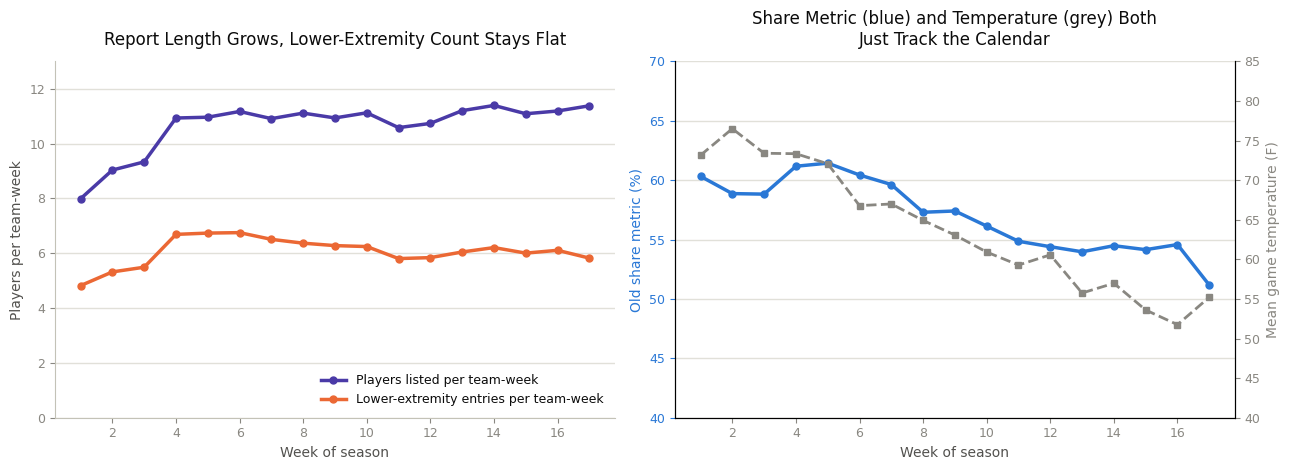

In [ ]:
# Visualizing the problem the data above is showing to justify my choice.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# Left panel: report length against lower extremity count, week by week. The gap between these two lines opening up is the denominator drifting out from under the share metric.
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, color="#e1e0d9", linewidth=1)
ax1.plot(week_drift.index, week_drift["mean_listed"], marker="o", markersize=5, linewidth=2.5,
         color="#4a3aa7", label="Players listed per team-week", zorder=3)
ax1.plot(week_drift.index, week_drift["mean_le"], marker="o", markersize=5, linewidth=2.5,
         color="#eb6834", label="Lower-extremity entries per team-week", zorder=3)
ax1.set_ylim(0, 13)
ax1.set_xlabel("Week of season", color="#52514e", fontsize=10)
ax1.set_ylabel("Players per team-week", color="#52514e", fontsize=10)
ax1.set_title("Report Length Grows, Lower-Extremity Count Stays Flat", fontsize=12, color="#0b0b0b", pad=12)
ax1.tick_params(colors="#898781", labelsize=9)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.spines["left"].set_color("#c3c2b7")
ax1.spines["bottom"].set_color("#c3c2b7")
legend = ax1.legend(loc="lower right", frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color("#0b0b0b")

# Right panel: the share metric and temperature plotted against week on a twin axis. They decline together purely because both are functions of the calendar.
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, color="#e1e0d9", linewidth=1)
ax2.plot(week_drift.index, week_drift["share"] * 100, marker="o", markersize=5, linewidth=2.5,
         color="#2a78d6", zorder=3)
ax2.set_ylim(40, 70)
ax2.set_xlabel("Week of season", color="#52514e", fontsize=10)
ax2.set_ylabel("Old share metric (%)", color="#2a78d6", fontsize=10)
ax2.tick_params(colors="#898781", labelsize=9)
ax2.tick_params(axis="y", colors="#2a78d6")

# twinx gives me a second y axis on the same x axis so temperature can share the plot despite being on a completely different scale.
ax2b = ax2.twinx()
ax2b.plot(week_drift.index, week_drift["mean_temp"], marker="s", markersize=4, linewidth=2,
          linestyle="--", color="#898781", zorder=3)
ax2b.set_ylabel("Mean game temperature (F)", color="#898781", fontsize=10)
ax2b.tick_params(axis="y", colors="#898781", labelsize=9)
ax2b.set_ylim(40, 85)
for spine in ["top"]:
    ax2.spines[spine].set_visible(False)
    ax2b.spines[spine].set_visible(False)
ax2.set_title("Share Metric (blue) and Temperature (grey) Both\nJust Track the Calendar", fontsize=12, color="#0b0b0b", pad=12)

plt.tight_layout()
plt.show()

         team_weeks  le_entries  le_per_team_week
surface                                          
grass          1174        7191             6.125
turf           1064        6388             6.004


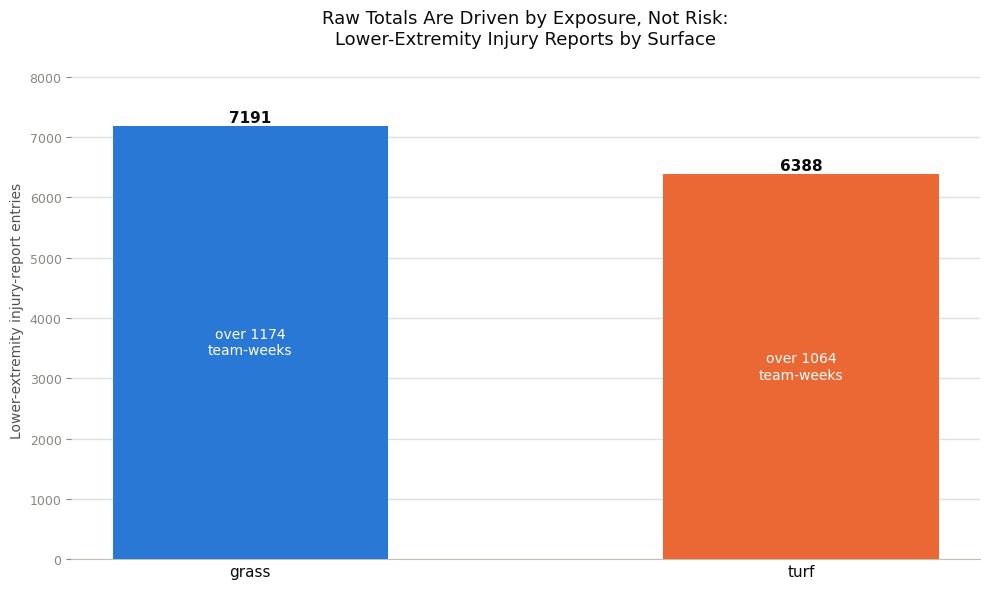

In [ ]:
# First look at the data: raw totals of lower extremity entries split by surface.
surface_panel = team_week_summary.dropna(subset=["surface"])
surface_counts = (
    surface_panel
    .groupby("surface")["lower_extremity_count"]
    .sum()
    .reindex(["grass", "turf"])
)


surface_exposure = surface_panel.groupby("surface").size().reindex(["grass", "turf"])
print(pd.DataFrame({
    "team_weeks": surface_exposure,
    "le_entries": surface_counts,
    "le_per_team_week": (surface_counts / surface_exposure).round(3),
}))

# Blue for grass and orange for turf.
colors = {"grass": "#2a78d6", "turf": "#eb6834"}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1)

bars = ax.bar(
    surface_counts.index, surface_counts.values,
    color=[colors[s] for s in surface_counts.index], width=0.5, zorder=3,
)

# Printing the exact count above each bar and the team week count underneath it.
for bar, value, exposure in zip(bars, surface_counts.values, surface_exposure.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, value + 8, f"{int(value)}",
        ha="center", va="bottom", fontsize=11, color="#0b0b0b", fontweight="bold",
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, value / 2, f"over {int(exposure)}\nteam-weeks",
        ha="center", va="center", fontsize=10, color="#ffffff",
    )

ax.set_title("Raw Totals Are Driven by Exposure, Not Risk:\nLower-Extremity Injury Reports by Surface", fontsize=13, color="#0b0b0b", pad=12)
ax.set_ylabel("Lower-extremity injury-report entries", color="#52514e", fontsize=10)
ax.tick_params(axis="x", labelsize=11, colors="#0b0b0b", length=0)
ax.tick_params(axis="y", labelsize=9, colors="#898781")


for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")


ax.set_ylim(0, max(surface_counts.values) * 1.15)

plt.tight_layout()
plt.show()

          mean    std  size     se     ci
surface                                  
grass    6.125  2.772  1174  0.081  0.159
turf     6.004  2.838  1064  0.087  0.171

Turf minus grass: -0.121 entries per team-week
95% CI: [-0.354, +0.111]


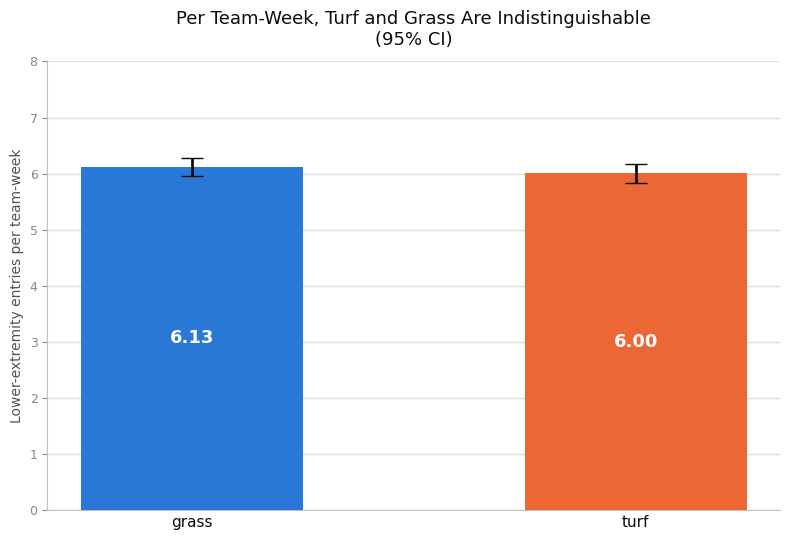

In [ ]:
# The same chart, but with the share metric.
surface_stats = (
    surface_panel.groupby("surface")["lower_extremity_count"]
    .agg(["mean", "std", "size"])
    .reindex(["grass", "turf"])
)
surface_stats["se"] = surface_stats["std"] / np.sqrt(surface_stats["size"])
surface_stats["ci"] = 1.96 * surface_stats["se"]


diff = surface_stats.loc["turf", "mean"] - surface_stats.loc["grass", "mean"]
diff_se = np.sqrt(surface_stats.loc["turf", "se"] ** 2 + surface_stats.loc["grass", "se"] ** 2)
print(surface_stats.round(3))
print(f"\nTurf minus grass: {diff:+.3f} entries per team-week")
print(f"95% CI: [{diff - 1.96 * diff_se:+.3f}, {diff + 1.96 * diff_se:+.3f}]")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1)

bars = ax.bar(
    surface_stats.index, surface_stats["mean"],
    yerr=surface_stats["ci"], capsize=8, error_kw={"elinewidth": 2, "ecolor": "#0b0b0b"},
    color=[colors[s] for s in surface_stats.index], width=0.5, zorder=3,
)
for bar, value in zip(bars, surface_stats["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value / 2, f"{value:.2f}",
            ha="center", va="center", fontsize=13, color="#ffffff", fontweight="bold")

ax.set_title("Per Team-Week, Turf and Grass Are Indistinguishable\n(95% CI)", fontsize=13, color="#0b0b0b", pad=12)
ax.set_ylabel("Lower-extremity entries per team-week", color="#52514e", fontsize=10)
ax.set_ylim(0, 8)
ax.tick_params(axis="x", labelsize=11, colors="#0b0b0b", length=0)
ax.tick_params(axis="y", labelsize=9, colors="#898781")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")

plt.tight_layout()
plt.show()

In [ ]:
# The categories of lower extremity injuries.
CATEGORY_KEYWORDS = {
    "Knee": ["knee"], "Ankle": ["ankle"], "Hamstring": ["hamstring"], "Groin": ["groin"],
    "Calf": ["calf"], "Quadricep": ["quad"], "Hip": ["hip"], "Thigh": ["thigh"],
    "Achilles": ["achilles"], "Toe": ["toe"], "Foot": ["foot", "feet", "heel"],
    "Other": ["shin", "fibula", "tibia", "glute", "adductor", "pelvis", "leg"],
}
'''
For each row I mash all four injury fields into one lowercase string and return the set of
categories that appear in it. A set rather than a list, because a player can have a knee and
an ankle noted at the same time and I want to count both, while still not counting a single
category twice just because it showed up in two of the four fields.
'''
def lower_extremity_categories(row):
    text = " ".join(str(v).lower() for v in row if pd.notna(v))
    return {cat for cat, keywords in CATEGORY_KEYWORDS.items() if any(kw in text for kw in keywords)}

team_week_injuries["le_categories"] = team_week_injuries[injury_fields].apply(lower_extremity_categories, axis=1)


exploded = (
    team_week_injuries[team_week_injuries["surface"].notna()]
    .explode("le_categories")
    .dropna(subset=["le_categories"])
)

'''
Cross tabulating category against surface. unstack pivots surface out into columns so I end
up with a grass column and a turf column side by side, then fillna(0) covers any empty
combination and the int cast undoes the float conversion that fillna causes.
'''
type_by_surface = exploded.groupby(["le_categories", "surface"]).size().unstack("surface").fillna(0).astype(int)

'''
Dividing each column by that surface's number of team weeks, for the same reason the headline
comparison needed it. Raw counts per category inherit the exposure imbalance, so grass looks
more common than it really is.
'''
type_rate_by_surface = type_by_surface.div(surface_exposure, axis=1)

# reindex with my own order so the table reads roughly most to least common instead of alphabetically.
category_order = ["Knee", "Ankle", "Hamstring", "Foot", "Groin", "Calf", "Hip", "Quadricep", "Toe", "Thigh", "Achilles", "Other"]
type_by_surface = type_by_surface.reindex(category_order)
type_rate_by_surface = type_rate_by_surface.reindex(category_order)

print("Raw entry counts:")
print(type_by_surface)
print("\nEntries per team-week:")
type_rate_by_surface.round(3)

Raw entry counts:
surface        grass  turf
le_categories             
Knee            2194  1942
Ankle           1661  1552
Hamstring        991   829
Foot             531   481
Groin            509   401
Calf             396   364
Hip              399   384
Quadricep        275   214
Toe              221   201
Thigh             88    81
Achilles          88    65
Other            114    88

Entries per team-week:


surface,grass,turf
le_categories,,
Knee,1.869,1.825
Ankle,1.415,1.459
Hamstring,0.844,0.779
Foot,0.452,0.452
Groin,0.434,0.377
Calf,0.337,0.342
Hip,0.340,0.361
Quadricep,0.234,0.201
Toe,0.188,0.189


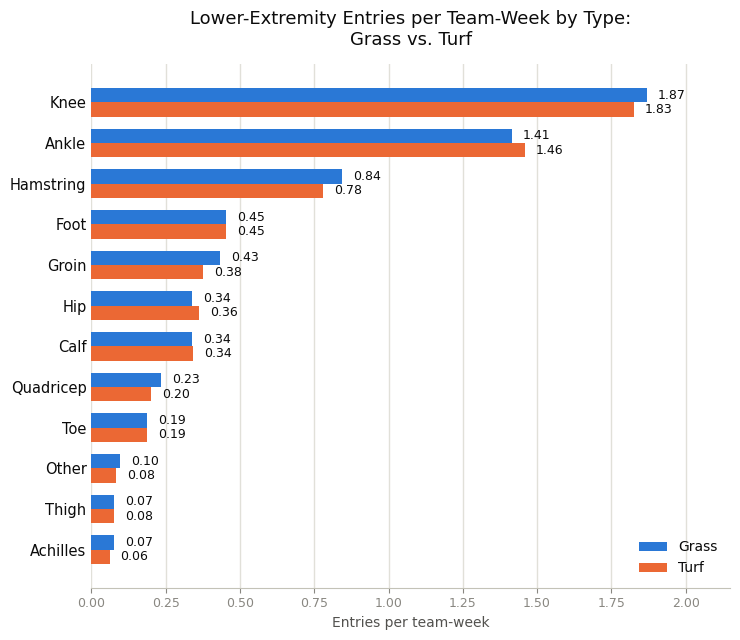

In [ ]:
# The data for the bar chart. Sorting ascending so the largest categories land at the top of the chart, since barh draws from the bottom up.
categories = type_rate_by_surface.sort_values(by=["grass", "turf"], ascending=True).index.tolist()
grass_rates = type_rate_by_surface.loc[categories, "grass"].values
turf_rates = type_rate_by_surface.loc[categories, "turf"].values


y = np.arange(len(categories))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#e1e0d9", linewidth=1)

bars_grass = ax.barh(y + bar_height / 2, grass_rates, height=bar_height, color="#2a78d6", label="Grass", zorder=3)
bars_turf = ax.barh(y - bar_height / 2, turf_rates, height=bar_height, color="#eb6834", label="Turf", zorder=3)

# Labeling every bar with its value. The offset is a percentage of the largest bar rather than
# a fixed number, so the labels stay clear of the bars no matter what scale the data lands on.
label_offset = max(grass_rates.max(), turf_rates.max()) * 0.02
for bar in list(bars_grass) + list(bars_turf):
    width = bar.get_width()
    ax.text(width + label_offset, bar.get_y() + bar.get_height() / 2, f"{width:.2f}",
            va="center", ha="left", fontsize=9, color="#0b0b0b")

ax.set_yticks(y)
ax.set_yticklabels(categories, fontsize=10.5, color="#0b0b0b")
ax.set_xlabel("Entries per team-week", color="#52514e", fontsize=10)
ax.set_title("Lower-Extremity Entries per Team-Week by Type:\nGrass vs. Turf", fontsize=13, color="#0b0b0b", pad=14)
ax.tick_params(axis="x", labelsize=9, colors="#898781")
ax.tick_params(axis="y", length=0)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.set_xlim(0, max(grass_rates.max(), turf_rates.max()) * 1.15)

# Building the legend manually so I can recolor the label text to match the rest of the chart.
legend = ax.legend(loc="lower right", frameon=False, fontsize=10)
for text in legend.get_texts():
    text.set_color("#0b0b0b")

plt.tight_layout()
plt.show()

In [ ]:
'''
Bringing temperature into the picture. I restrict to roofs that were genuinely open to the
weather, because every dome and closed roof row is sitting at the same 72 degrees I filled
in earlier. Those are not measurements, so leaving them in would pile up a fake spike at 72
and flatten whatever real temperature pattern exists.
'''
weather_weeks = team_week_summary[team_week_summary["roof"].isin(["outdoors", "open"])].dropna(subset=["surface"]).copy()

# Binning temperature into five ranges. I picked the cut points around thresholds that mean something physically (freezing, cool, mild, warm, hot).
temp_bins = [0, 32, 45, 60, 75, 120]
bin_labels = ["<=32", "33-45", "46-60", "61-75", "76+"]
weather_weeks["temp_bin"] = pd.cut(weather_weeks["temp"], bins=temp_bins, labels=bin_labels)

'''
Aggregating by bin and surface. mean_le is my real outcome, the average lower extremity
entries per team week, and sd_le plus team_weeks are what I need to put an interval on it.
I carry the true mean temperature of each bin because the bins are unequal width and plotting
them as evenly spaced labels would misrepresent how far apart they actually are.
mean_week is the confound check. If the cold bins sit late in the season and the warm bins sit
early, then a temperature comparison is partly a September versus December comparison.
old_share is the metric I retired, kept here only so I can put the two side by side.
'''
bin_stats = (
    weather_weeks.groupby(["temp_bin", "surface"], observed=True)
    .agg(team_weeks=("game_id", "size"), le_count=("lower_extremity_count", "sum"),
         mean_le=("lower_extremity_count", "mean"), sd_le=("lower_extremity_count", "std"),
         total_listed=("total_listed", "sum"), mean_temp=("temp", "mean"), mean_week=("week_game", "mean"))
    .reset_index()
)
bin_stats["old_share"] = bin_stats["le_count"] / bin_stats["total_listed"]

'''
My indoor comparison group: every dome and closed roof team week pooled together. This gives
me a flat climate controlled reference point to judge the outdoor bins against, on both the
real metric and the retired one.
'''
indoor_weeks = team_week_summary[team_week_summary["roof"].isin(["dome", "closed"])]
indoor_le = indoor_weeks["lower_extremity_count"].mean()
indoor_share = indoor_weeks["lower_extremity_count"].sum() / indoor_weeks["total_listed"].sum()
print(f"Indoor baseline: {indoor_le:.2f} entries per team-week, old share metric {indoor_share:.1%}")

bin_stats.round(3)

Indoor baseline: 5.87 entries per team-week, old share metric 56.2%


,temp_bin,surface,team_weeks,le_count,mean_le,sd_le,total_listed,mean_temp,mean_week,old_share
0,<=32,grass,58,340,5.862,2.243,646,21.655,14.966,0.526
1,<=32,turf,30,191,6.367,3.178,342,25.800,15.067,0.558
2,33-45,grass,162,988,6.099,2.396,1869,39.407,13.383,0.529
3,33-45,turf,88,547,6.216,2.507,1007,39.545,13.773,0.543
4,46-60,grass,292,1791,6.134,2.764,3194,53.514,11.432,0.561
5,46-60,turf,162,1047,6.463,3.044,1832,52.407,10.753,0.572
6,61-75,grass,280,1733,6.189,2.904,2962,68.071,8.086,0.585
7,61-75,turf,108,640,5.926,2.928,1077,66.333,4.685,0.594
8,76+,grass,244,1471,6.029,2.937,2482,81.770,5.697,0.593
9,76+,turf,28,181,6.464,3.533,294,80.143,3.571,0.616


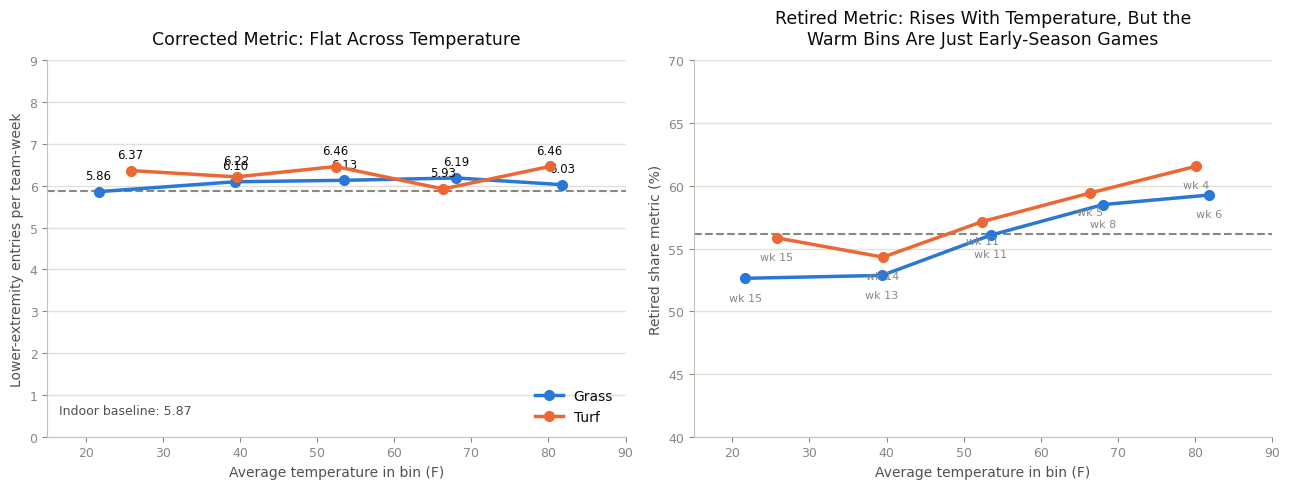

In [ ]:
# Plotting both metrics against temperature side by side to show the comparison.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors = {"grass": "#2a78d6", "turf": "#eb6834"}

# Left panel: the real outcome, entries per team week.
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, color="#e1e0d9", linewidth=1)
for surface in ["grass", "turf"]:
    sub = bin_stats[bin_stats["surface"] == surface].sort_values("mean_temp")
    ax1.plot(sub["mean_temp"], sub["mean_le"], marker="o", markersize=7, linewidth=2.5,
             color=colors[surface], label=surface.capitalize(), zorder=3)
    for x, y in zip(sub["mean_temp"], sub["mean_le"]):
        ax1.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=8.5, color="#0b0b0b")

# Drawing the indoor baseline as a dashed horizontal line rather than a third series, since it is one pooled number and not a trend across temperature.
ax1.axhline(indoor_le, color="#898781", linestyle="--", linewidth=1.5, zorder=2)
ax1.text(0.02, 0.06, f"Indoor baseline: {indoor_le:.2f}", transform=ax1.transAxes,
         fontsize=9, color="#52514e")
ax1.set_xlim(15, 90)

# Formatting the plot.
ax1.set_xticks([25, 50, 75, 100])
ax1.set_xticklabels(["32°F", "45°F", "60°F", "75°F"], fontsize=10, color="#52514e")
ax1.set_ylim(0, 9)
ax1.set_xlabel("Average temperature in bin (F)", color="#52514e", fontsize=10)
ax1.set_ylabel("Lower-extremity entries per team-week", color="#52514e", fontsize=10)
ax1.set_title("Corrected Metric: Flat Across Temperature", fontsize=12.5, color="#0b0b0b", pad=12)
ax1.tick_params(colors="#898781", labelsize=9)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.spines["left"].set_color("#c3c2b7")
ax1.spines["bottom"].set_color("#c3c2b7")
legend = ax1.legend(loc="lower right", frameon=False, fontsize=10)
for text in legend.get_texts():
    text.set_color("#0b0b0b")

# Right panel: the old metric, old share.
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, color="#e1e0d9", linewidth=1)
for surface in ["grass", "turf"]:
    sub = bin_stats[bin_stats["surface"] == surface].sort_values("mean_temp")
    ax2.plot(sub["mean_temp"], sub["old_share"] * 100, marker="o", markersize=7, linewidth=2.5,
             color=colors[surface], label=surface.capitalize(), zorder=3)
    for x, y, w in zip(sub["mean_temp"], sub["old_share"] * 100, sub["mean_week"]):
        ax2.annotate(f"wk {w:.0f}", (x, y), textcoords="offset points", xytext=(0, -16),
                     ha="center", fontsize=8, color="#898781")

ax2.axhline(indoor_share * 100, color="#898781", linestyle="--", linewidth=1.5, zorder=2)
ax2.set_xlim(15, 90)
ax2.set_ylim(40, 70)
ax2.set_xlabel("Average temperature in bin (F)", color="#52514e", fontsize=10)
ax2.set_ylabel("Retired share metric (%)", color="#52514e", fontsize=10)
ax2.set_title("Retired Metric: Rises With Temperature, But the\nWarm Bins Are Just Early-Season Games", fontsize=12.5, color="#0b0b0b", pad=12)
ax2.tick_params(colors="#898781", labelsize=9)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
ax2.spines["left"].set_color("#c3c2b7")
ax2.spines["bottom"].set_color("#c3c2b7")

plt.tight_layout()
plt.show()

In [ ]:
'''
Now the same noise check as before, but on the corrected outcome. The question is whether the
turf minus grass gap inside each temperature bin is big enough to take seriously.
pivot puts grass and turf side by side in the same row for each bin, which is what lets me
subtract one from the other.
'''
pivot = bin_stats.pivot(index="temp_bin", columns="surface", values=["team_weeks", "mean_le", "sd_le", "mean_temp"])
gap = pd.DataFrame({
    "mean_temp": pivot[("mean_temp", "turf")],
    "grass_mean": pivot[("mean_le", "grass")],
    "turf_mean": pivot[("mean_le", "turf")],
    "grass_sd": pivot[("sd_le", "grass")],
    "turf_sd": pivot[("sd_le", "turf")],
    "grass_n": pivot[("team_weeks", "grass")],
    "turf_n": pivot[("team_weeks", "turf")],
})

# diff is the turf minus grass gap in each bin, so a positive number means turf looks worse.
gap["diff"] = gap["turf_mean"] - gap["grass_mean"]

'''
Standard error of a difference between two means: each group's variance divided by its own
#ample size, added together, then square rooted. The 95% interval is the difference plus and
minus 1.96 standard errors.
I switched to this from the two proportion formula I used before, because my outcome is now a
count per team week rather than a proportion of listed players. That also makes the
independence assumption far less of a stretch, since the unit is one team's game rather than
individual players who share a roster, a schedule, and a training staff.

'''
gap["se"] = np.sqrt(
    gap["turf_sd"] ** 2 / gap["turf_n"]
    + gap["grass_sd"] ** 2 / gap["grass_n"]
)
gap["ci_lo"] = gap["diff"] - 1.96 * gap["se"]
gap["ci_hi"] = gap["diff"] + 1.96 * gap["se"]
gap = gap.sort_values("mean_temp")
gap.round(3)

,mean_temp,grass_mean,turf_mean,grass_sd,turf_sd,grass_n,turf_n,diff,se,ci_lo,ci_hi
temp_bin,,,,,,,,,,,
<=32,25.800,5.862,6.367,2.243,3.178,58.0,30.0,0.505,0.651,-0.771,1.780
33-45,39.545,6.099,6.216,2.396,2.507,162.0,88.0,0.117,0.327,-0.524,0.758
46-60,52.407,6.134,6.463,2.764,3.044,292.0,162.0,0.329,0.289,-0.237,0.895
61-75,66.333,6.189,5.926,2.904,2.928,280.0,108.0,-0.263,0.331,-0.912,0.385
76+,80.143,6.029,6.464,2.937,3.533,244.0,28.0,0.436,0.694,-0.924,1.795


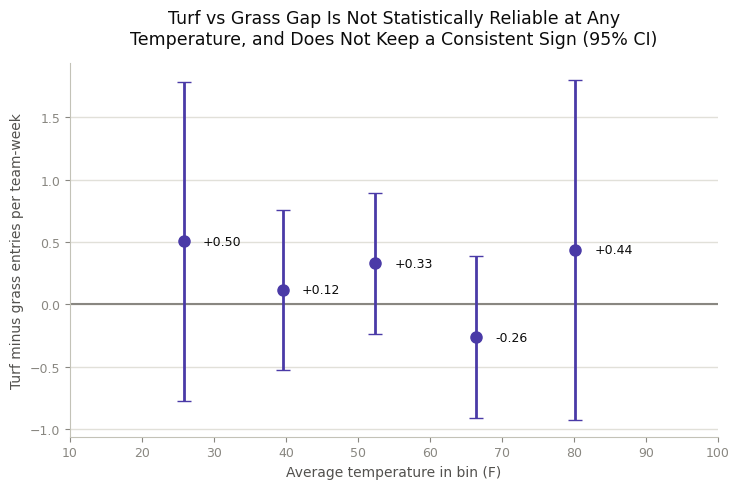

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1)

# The line at zero is the entire point of this chart. Any interval that crosses it means the
# gap at that temperature is not distinguishable from no difference at all.
ax.axhline(0, color="#898781", linewidth=1.5, zorder=2)

x = gap["mean_temp"].values
diff_vals = gap["diff"].values
lo = gap["ci_lo"].values
hi = gap["ci_hi"].values

# errorbar wants the yerr values as distances from the point rather than absolute positions,
# so I subtract to get the length of the lower whisker and the upper whisker.
ax.errorbar(x, diff_vals, yerr=[diff_vals - lo, hi - diff_vals], fmt="o", markersize=8,
            color="#4a3aa7", ecolor="#4a3aa7", elinewidth=2, capsize=5, zorder=3)

# Labeling each point with a signed value so the direction of the gap is explicit and nobody
# has to work out the sign from the axis.
for xi, yi in zip(x, diff_vals):
    ax.annotate(f"{yi:+.2f}", (xi, yi), textcoords="offset points", xytext=(14, 0),
                ha="left", va="center", fontsize=9, color="#0b0b0b")

ax.set_xlim(10, 100)
ax.set_xlabel("Average temperature in bin (F)", color="#52514e", fontsize=10)
ax.set_ylabel("Turf minus grass entries per team-week", color="#52514e", fontsize=10)
ax.set_title("Turf vs Grass Gap Is Not Statistically Reliable at Any\nTemperature, and Does Not Keep a Consistent Sign (95% CI)", fontsize=12.5, color="#0b0b0b", pad=14)
ax.tick_params(colors="#898781", labelsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")

plt.tight_layout()
plt.show()

## Conclusion

My original research question was whether the rate of lower-extremity injury-report entries is higher for teams playing on turf than on grass, and whether that difference is moderated by temperature. Here is what the data actually showed, and what I think it means.

### The metric change that changed the answer

My first pass measured the **share** of a team's injury report that was lower body. That was the wrong denominator, and fixing it flipped one of my two headline findings.

The diagnostic makes it plain. Report length climbs from about 8.0 listed players in week 1 to about 11.4 by week 17, while lower-extremity entries per team-week stay flat around 6. So the share falls from roughly 60% early in the season to 51% late, entirely because the denominator grows. Temperature correlates with week number at **-0.649** in the weather-exposed games, meaning warm games are mostly September games and cold games are mostly December games. Put those two facts together and the share metric will always show "injuries rise with temperature," whether or not temperature does anything at all. My original temperature finding was the season calendar wearing a temperature costume.

### What I found with the corrected metric

- **Raw counts are about exposure, not risk.** Grass produced 7,191 lower-extremity entries across 1,174 team-weeks; turf produced 6,388 across 1,064. More grass team-weeks means more chances to accumulate injuries, which is the whole explanation for the gap in the totals.
- **Per team-week, the two surfaces are indistinguishable.** Grass averaged **6.13** entries per team-week and turf **6.00**. The turf minus grass difference is **-0.12**, with a 95% interval of **[-0.35, +0.11]**. The point estimate slightly favors turf, and the interval comfortably contains zero.
- **The temperature effect disappeared.** Across the five temperature bins, entries per team-week range from 5.86 to 6.46 with no trend in either direction. The indoor, climate-controlled baseline is 5.87, which sits at the bottom of that range but well inside it. Whatever is going on, temperature is not moving the per-game injury count.
- **The turf edge was not even consistent in direction.** By bin the gap runs +0.51, +0.12, +0.33, **-0.26**, +0.44 as temperature rises, and every single interval crosses zero. My earlier claim that turf came out worse in every bin was an artifact of the share metric, not a finding.
- **No single injury type tells a different story.** Per team-week, grass versus turf is 1.87 vs 1.83 for knees, 1.42 vs 1.46 for ankles, and 0.84 vs 0.78 for hamstrings. Nothing separates.

### Limitations

- **I am counting report entries, not distinct injuries.** A player with a four-week ankle problem shows up in four consecutive team-weeks. So this measures lower-extremity burden on the injury report, not the rate of newly occurring injuries, and a surface that produces longer-lasting injuries would look the same as one that produces more of them.
- **Surface is badly confounded with roof.** Turf accounts for 648 of the 804 indoor team-weeks, while grass accounts for 1,036 of the 1,452 outdoor ones. Restricting the temperature analysis to weather-exposed games reduces this but does not remove it, and a turf versus grass comparison is partly an indoor versus outdoor comparison.
- **The injury-to-game link is an assumption.** The "next week the team played" join assumes an injury appearing on the following report was caused by the prior game. Reasonable, but unverified without play-by-play injury data.
- **Lower extremity is keyword matched** against free-text fields typed by team staff, which is not a medically verified injury log.
- **This is observational and aggregated** to the team-week, so even a clean gap would show association rather than establish turf as the mechanism. Roster composition, team training habits, and travel all go uncontrolled here.
- **One fix I made barely mattered.** Only 1 of 2,256 team-weeks had nobody listed on the following report, so handling zero-injury weeks correctly changed essentially nothing. Worth stating rather than presenting it as a meaningful correction.

### Bottom line

- **I do not have evidence that turf produces more lower-extremity injuries.** This is stronger than "the result was uncertain." With a per-game denominator, the point estimate sits on the grass side of zero, the sign flips across temperature bins, and every interval includes no difference.
- **That is not the same as saying players are wrong.** Injury-report entries capture neither severity, nor mechanism, nor games missed, and a surface that hurts more when it hurts would not show up in a count like this. Josh Allen and others are describing how the surface feels under load, which this dataset simply cannot see.
- **Nothing here supports a league-wide grass mandate on injury grounds,** at least not from this data. Turf's practical case, cheaper year-round maintenance and the ability to host concerts and other events between games, is concrete and measurable. The injury case against it is, in this analysis, absent rather than merely weak.
- **The real lesson for me is the denominator.** I had a clean pipeline, a careful bye-week join, and a defensible surface classification, and I still got the wrong answer on temperature because I never checked that my outcome variable measured what I assumed it measured.

# AI Transparency

I used AI to write the code of the visualizations and joining the data to save time. However all the decisions pertaining towards which charts and graphs I wanted and the data cleaning alongside the explanation as to why behind was driven by me.<br>

In addition, I used AI to clean up the messy notebook of a bunch of code and the testing of different ideas scattered around to make it a easy to read and follow from top to bottom.